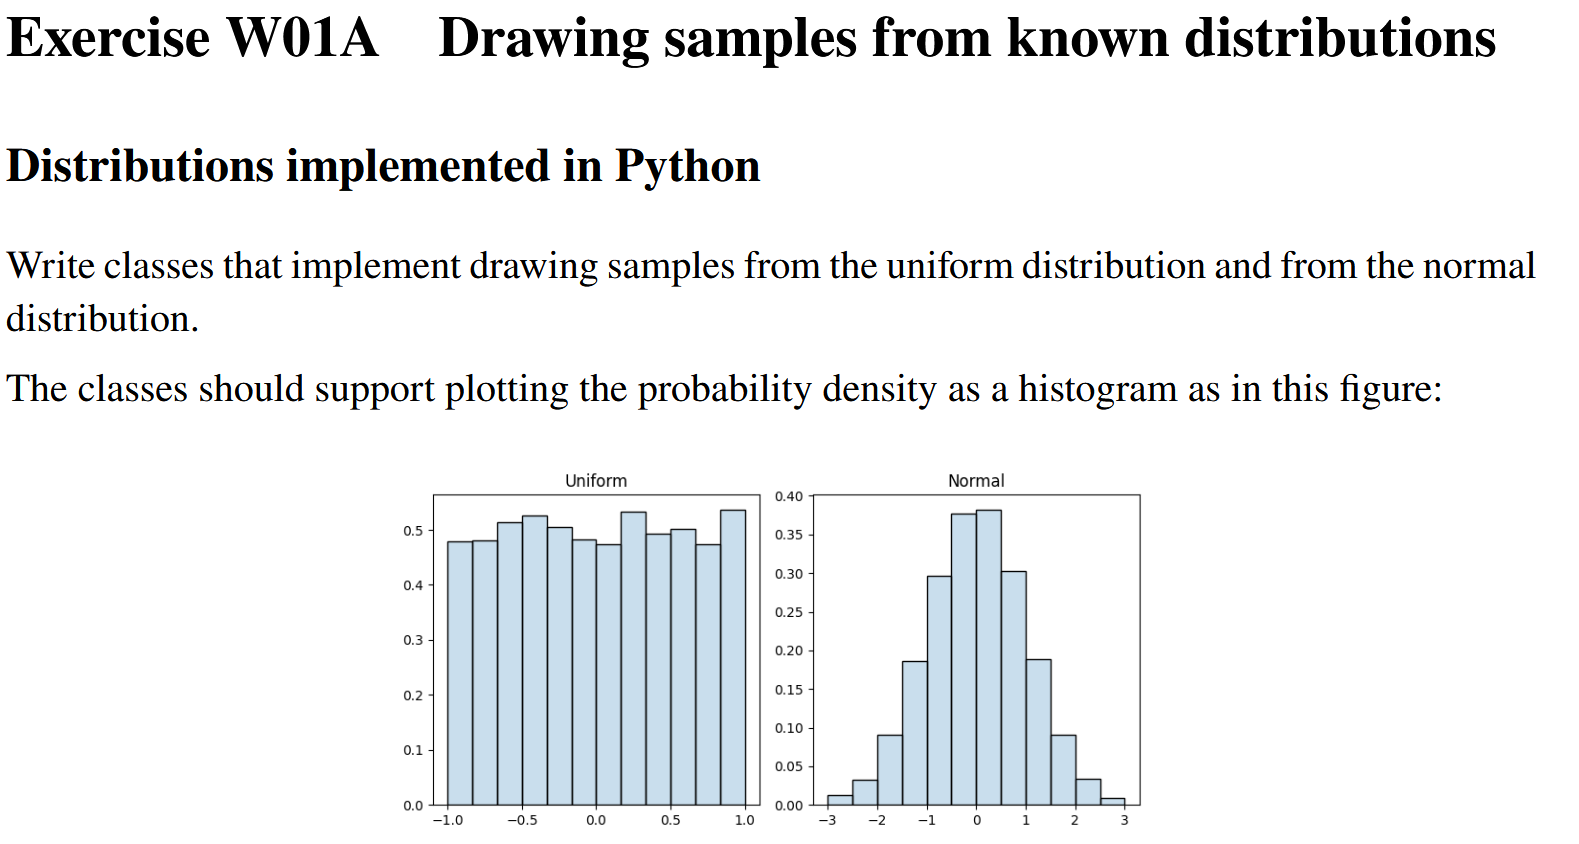

In [26]:
import numpy as np
import matplotlib.pyplot as plt

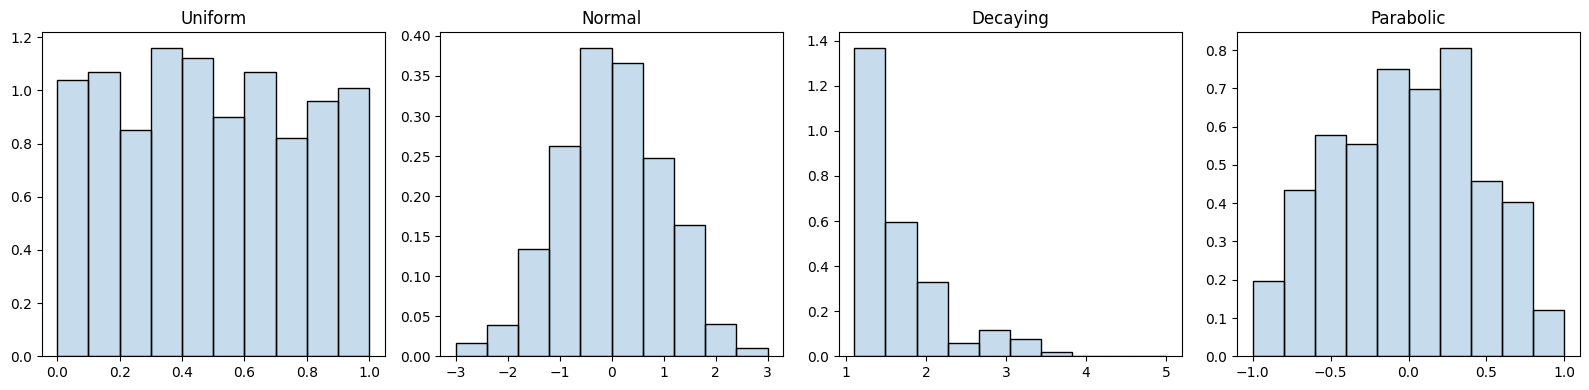

In [27]:
class Distribution:
    def __init__(self, xmin=0, xmax=1, N=1000):
        """
        Class to initialize the range and number of points drawn from distributions

        Arguments: 
            float xmin: minimum value for x
            float xmax: maximum value for x
            int N: Number of points drawn
        """

        self.xmin = xmin
        self.xmax = xmax
        self._set_xvals(N)

    def plot(self, ax, bins=10):
        """
        Function for plotting histogram of distribution. 

        Arguments: 
            ax: matplotlib ax object to draw histogram in
            int bins: number of bins to but data into 
        """

        xedges = np.linspace(self.xmin, self.xmax, bins+1)
        xcenters = (xedges[:-1] + xedges[1:]) / 2
        xwidth = xedges [1] - xedges [0]
        bars, _ = np.histogram(self.xvals, xedges)
        P = bars / np.sum(bars) / xwidth
        ax.bar(xcenters, P, width=xwidth, facecolor ='C0', alpha =0.25)
        ax.bar(xcenters, P, width=xwidth, facecolor ='None', edgecolor ='k')
        ax.set_title(self.__class__.__name__ )

class Uniform(Distribution):
    """ Uniform distribution from notes"""
    def _set_xvals(self, N):
        self.xvals = np.random.rand(N) * (self.xmax - self.xmin) + self.xmin

class Normal(Distribution):
    """ Normal distribution from notes"""
    def _set_xvals(self, N):
        self.xvals = np.random.randn(N)

class Decaying(Distribution):
    """ Exponential decaying distribution using inverse-transform sampling """
    def __init__(self, λ=2, xmin=1, xmax=10):
        assert λ > 0, "λ must be bigger then 0"
        self.λ = λ

        super().__init__(xmin=xmin, xmax=xmax)

    def _set_xvals(self, N):
        U = Uniform(0, 1, N).xvals
        self.xvals = -np.log(1-U) / self.λ

class Parabolic(Distribution):
    """ Parabolic distribution using rejection sampling """
    def _set_xvals(self, N):
        x = Uniform(xmin=-1, xmax=1, N=N).xvals
        y = Uniform(xmin=0, xmax=1, N=N).xvals
        p = 3/4 * (1 - x**2)
        self.xvals = np.array([a for a,b,c in zip(x,y,p) if b < c])


uniform = Uniform()
normal = Normal(xmin=-3, xmax=3)
decaying = Decaying(λ=2, xmin=1.1, xmax=5)
parabolic = Parabolic(xmin=-1, xmax=1)
distributions = [uniform, normal, decaying, parabolic]
N = len(distributions)

fig, axes = plt.subplots(1, N, figsize =(4*N, 4))
for distribution, ax in zip(distributions, axes):
    distribution.plot(ax)
fig.tight_layout()


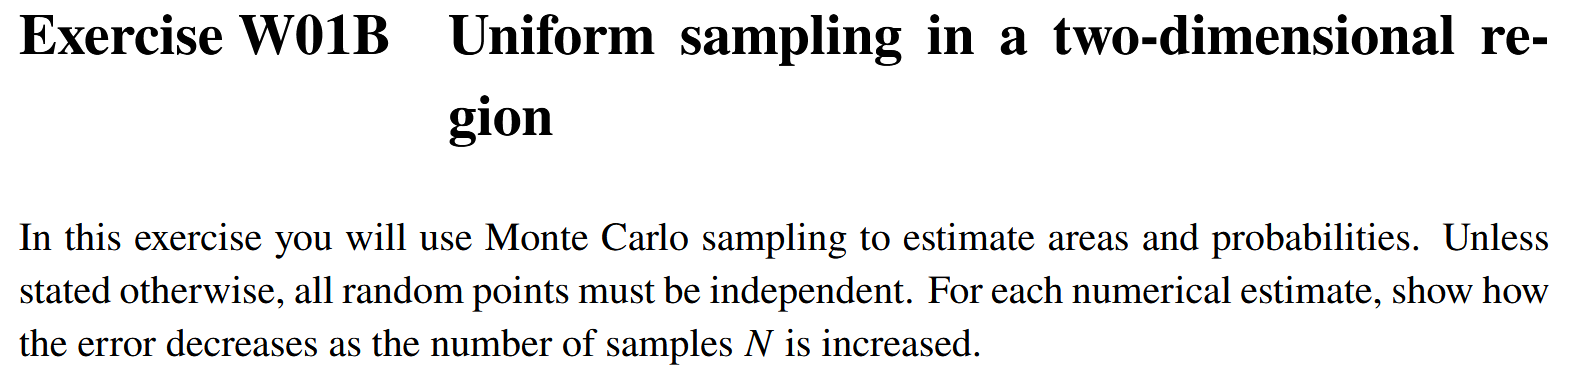

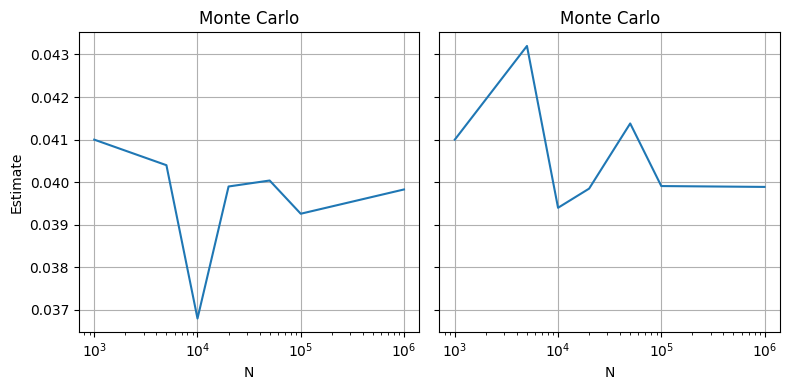

Estimated value of pi using N=1_000_000:
 3.140624 


In [28]:
class MonteCarlo:
    def __init__(self, xmin=0, xmax=1, ymin=0, ymax=1, N=10000):
        """
        Class for making Monte Carlo simulations. 
        makes x and y arrays of length N, 
        with values uniformly drawn from (xmin,xmax) and (ymin, ymax). 

        Then runs an indication function on the points. 

        Arguments: 
            float bounds: 
            int N: Number of points used 

        """
        self.N = N 
        self.xmin, self.xmax = (xmin, xmax)
        self.ymin, self.ymax = (ymin, ymax)

        # Run sampler
        self._sample()

        # Run indicator
        self._indicator()

    def _sample(self):
        """
        Default uniform sampler
        """
        self.x = Uniform(self.xmin, self.xmax, self.N).xvals
        self.y = Uniform(self.ymin, self.ymax, self.N).xvals

    def _indicator(self):
        print("Indicator not defined")
        pass


class Square(MonteCarlo):
    def __init__(self, sq_xmin, sq_xmax, sq_ymin, sq_ymax, xmin=0, xmax=1, ymin=0, ymax=1, N=10000):
        """
        Indicator class for a square
        """
        self.sq_xmin = sq_xmin
        self.sq_xmax = sq_xmax
        self.sq_ymin = sq_ymin
        self.sq_ymax = sq_ymax

        super().__init__(xmin, xmax, ymin, ymax, N=N)

    def _indicator(self):
        # Check if (x,y) in D, numpy defaults to values 0 and 1
        inside = (self.x > self.sq_xmin) & (self.x < self.sq_xmax) & (self.y > self.sq_ymin) & (self.y < self.sq_ymax)
        self.xvals = np.sum(inside) / self.N 

class UnitCircle(MonteCarlo):
    """
    Indicator class for unit circle
    Could be changed to be any circle
    """
    def _indicator(self):
        # Check if (x,y) in D, numpy defaults to values 0 and 1
        inside = (self.x**2 + self.y**2) < 1
        self.xvals = 4* np.sum(inside) / self.N 

D1 = lambda N: Square(sq_xmin=0, sq_xmax=0.2, sq_ymin=0, sq_ymax=0.2, N=N)
D2 = lambda N: Square(sq_xmin=0.8, sq_xmax=1, sq_ymin=0, sq_ymax=0.2, N=N)
Do = lambda N: UnitCircle(N=N)

comparings = [D1, D2]
N = len(comparings)

fig, axes = plt.subplots(1, N, figsize=(4*N, 4), sharey=True)
axes[0].set_ylabel("Estimate")
n = [1000, 5000, 10000, 20000, 50000, 100000, 1_000_000]
for c, ax in zip(comparings, axes):
    counts = [c(x).xvals for x in n]
    ax.plot(n, counts)
    ax.set_title("Monte Carlo")
    ax.set_xlabel("N")
    ax.set_xscale("log")
    ax.grid()

fig.tight_layout()
plt.show()

pi = Do(1_000_000).xvals
print(f"Estimated value of pi using N=1_000_000:\n {pi} ")


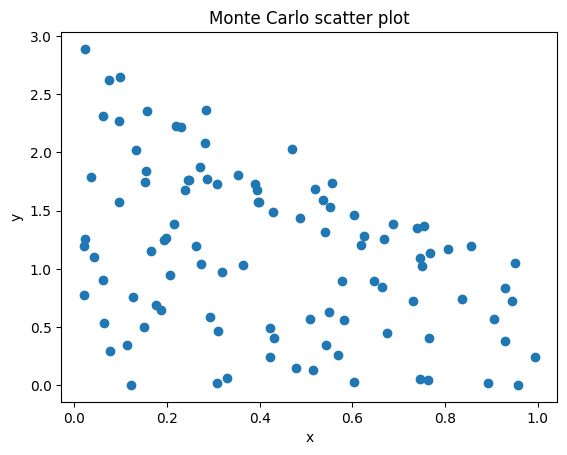

P1 (Hits in D1): 0.019894
P2 (Hits in D2): 0.019669
Po (Hits in Do): 0.392069
Area of P1: 0.039788 - Area of P2: 0.039338
Estimate of π: 3.136552


Text(0, 0.5, 'π')

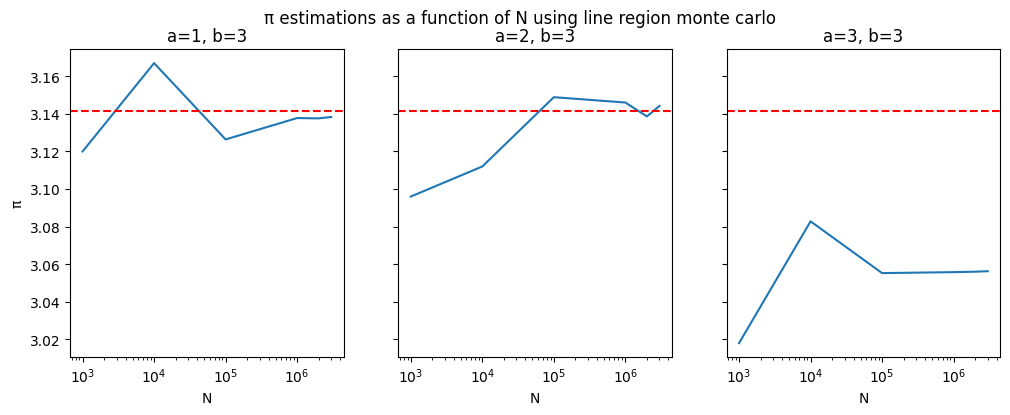

In [29]:
class BelowLine(Distribution):
    def __init__(self, a, b, xmin=0, xmax=1, ymin=0, N=10000):
        """
        Distribution subclass for picking N points below a line defined by b-ax
        Uses equation 1.18 and 1.19

        Arguments: 
            float a, b: parameters of line
            float bounds: 
        """
        self.a = a
        self.b = b
        self.ymin = ymin
        super().__init__(xmin=xmin, xmax=xmax, N=N)
        self._set_yvals(N)

    def _set_xvals(self, N):
        u = Uniform(self.xmin, self.xmax, N).xvals
        self.xvals = (self.b - np.sqrt(self.b**2 - 2*self.a * (self.b - self.a/2) * u))/self.a

    def _set_yvals(self, N):
        self.yvals = Uniform(self.ymin, (self.b - self.a * self.xvals), N).xvals



class LineRegion(MonteCarlo): 
    def __init__(self, a, b, xmin=0, xmax=1, ymin=0, N=10000):
        """
        MonteCarlo subclass to draw point from BelowLine distribution instead of Uniform
        """
        self.a = a
        self.b = b 

        super().__init__(xmin=xmin, xmax=xmax, ymin=ymin, N=N)

    def _indicator(self):
        inside = self.y < (self.b - self.a * self.x)
        self.xvals = np.sum(inside) / self.N

    def _sample(self):
        dist = BelowLine(self.a, self.b, self.xmin, self.xmax, self.ymin, self.N)
        self.x = dist.xvals
        self.y = dist.yvals


class RegionSquare(LineRegion):
    def __init__(self, a, b, sq_xmin, sq_xmax, sq_ymin, sq_ymax, N=10000):
        """
        Indicator subclass to check indicators against the line region monte carlo
        """
        self.sq_xmin = sq_xmin
        self.sq_xmax = sq_xmax
        self.sq_ymin = sq_ymin
        self.sq_ymax = sq_ymax

        super().__init__(a=a, b=b, xmin=0, xmax=1, ymin=0, N=N)

    def _indicator(self):
        # Check if (x,y) in D, numpy defaults to values 0 and 1
        inside = (self.x > self.sq_xmin) & (self.x < self.sq_xmax) & (self.y > self.sq_ymin) & (self.y < self.sq_ymax)
        self.xvals = np.sum(inside) / self.N 

class RegionCircle(LineRegion):
    def __init__(self, a, b, N=10000):
        """
        Indicator for unit circle against line region monte carlo
        """
        super().__init__(a=a, b=b, xmin=0, xmax=1, ymin=0, N=N)

    def _indicator(self):
        # Check if (x,y) in D, numpy defaults to values 0 and 1
        inside = (self.x**2 + self.y**2) <= 1
        self.xvals = np.sum(inside) / self.N 


a, b = 2, 3
N_samples = 1_000_000


points = LineRegion(a, b, N=100)

plt.scatter(points.x, points.y)
plt.title("Monte Carlo scatter plot")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

P1 = RegionSquare(a=a, b=b, sq_xmin=0, sq_xmax=0.2, sq_ymin=0, sq_ymax=0.2, N=N_samples)
P2 = RegionSquare(a=a, b=b, sq_xmin=0.8, sq_xmax=1.0, sq_ymin=0, sq_ymax=0.2, N=N_samples)
Po = RegionCircle(a=a, b=b, N=N_samples)

print(f"P1 (Hits in D1): {P1.xvals}")
print(f"P2 (Hits in D2): {P2.xvals}")
print(f"Po (Hits in Do): {Po.xvals}")

A = b - a/2
print(f"Area of P1: {A*P1.xvals} - Area of P2: {A*P2.xvals}")

print(f"Estimate of π: {4*A*Po.xvals}")


fig, axs = plt.subplots(1, 3, figsize=(12,4), sharey=True)
n = [1000, 10_000, 100_000, 1_000_000, 2_000_000, 3_000_000]

for i in (1, 2, 3):
    A = 3 - i/2
    axs[i-1].plot(n, [4*A*RegionCircle(a=i, b=3, N=j).xvals for j in n])
    axs[i-1].set_title(f"a={i}, b={b}")
    axs[i-1].set_xlabel("N")
    axs[i-1].axhline(np.pi, color='red', linestyle='--')
    axs[i-1].set_xscale("log")

fig.suptitle("π estimations as a function of N using line region monte carlo")
axs[0].set_ylabel("π")

If the points are not contained in the quater circle, it is not estimating π, but instead 4 times the overlap between the area and the quater circle. This can be seen in a=3, b=3 as some of the circle will not be contained 

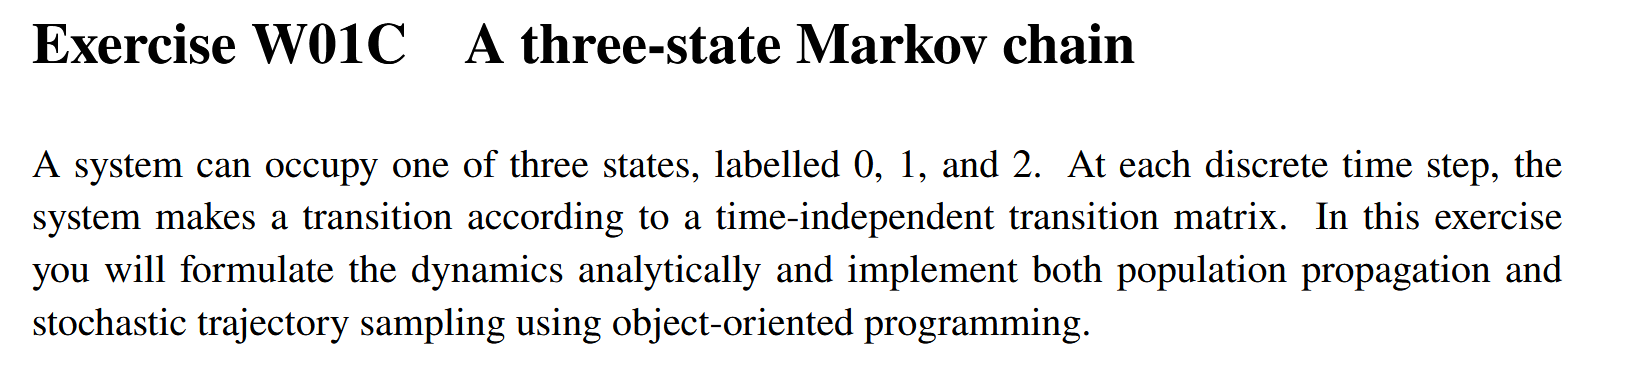

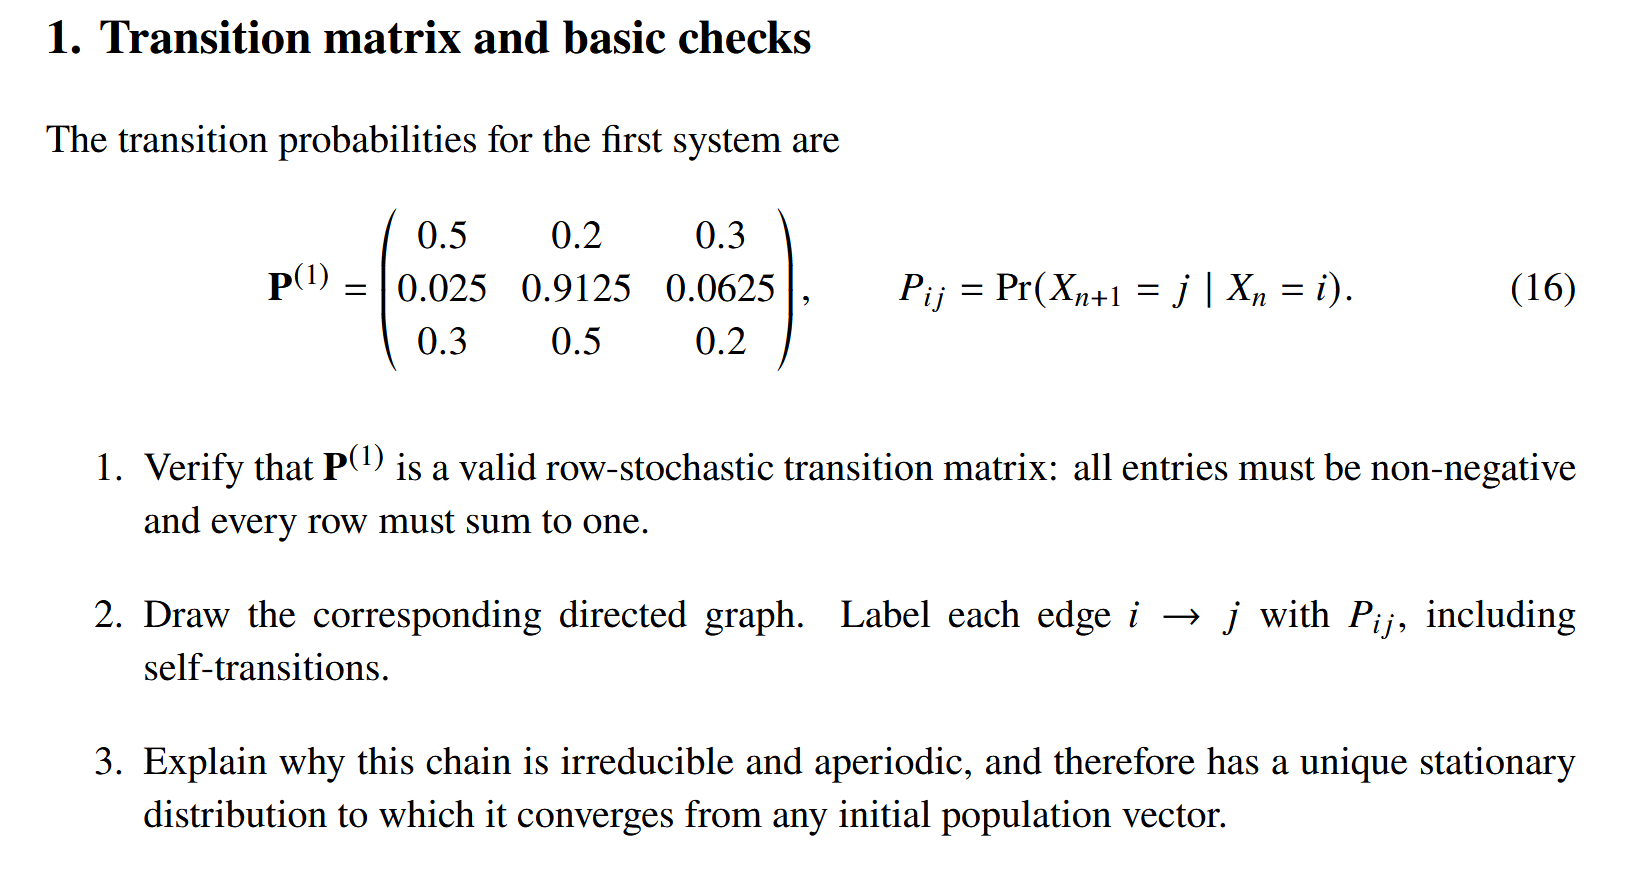

In [30]:
P1 = np.array([[0.5, 0.2, 0.3], 
              [0.025, 0.9125, 0.0625], 
              [0.3, 0.5, 0.2]])
I = np.array([1, 1, 1])
print(f"Sums of rows: {(P1 @ I)}")

Sums of rows: [1. 1. 1.]


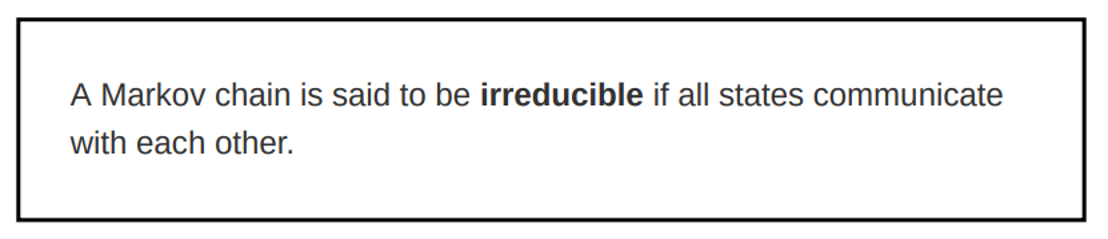
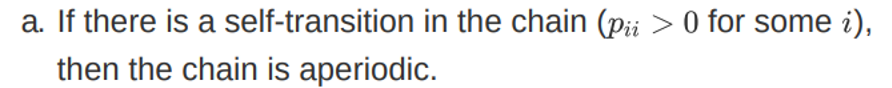

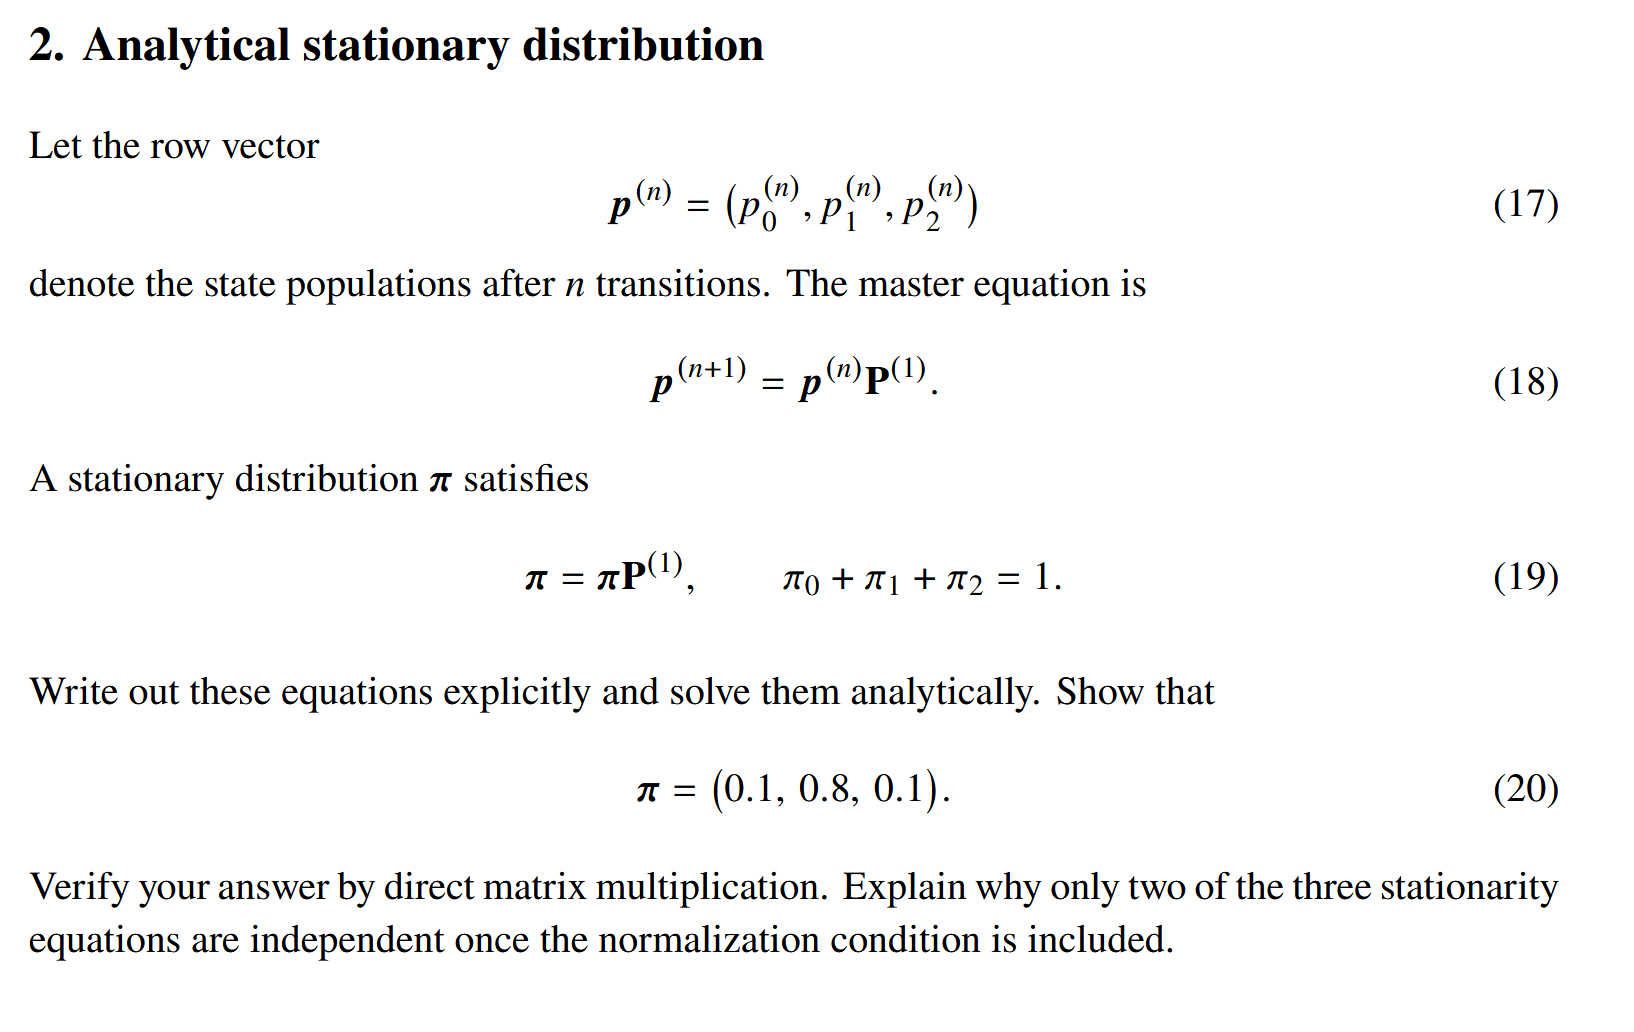

### Analytical stationary distribution

The stationary distribution $\pi = (\pi_0, \pi_1, \pi_2)$ satisfies $\pi = \pi P^{(1)}$ and $\pi_0 + \pi_1 + \pi_2 = 1$. 

**Explicit Equations:**
1) $\pi_0 = 0.5\pi_0 + 0.025\pi_1 + 0.3\pi_2$
2) $\pi_1 = 0.2\pi_0 + 0.9125\pi_1 + 0.5\pi_2$
3) $\pi_2 = 0.3\pi_0 + 0.0625\pi_1 + 0.2\pi_2$

**Analytical Solution:**
From Equation (1), isolate $\pi_1$:
$$0.5\pi_0 = 0.025\pi_1 + 0.3\pi_2$$
Multiply by 40: 
$$20\pi_0 = \pi_1 + 12\pi_2 \implies \pi_1 = 20\pi_0 - 12\pi_2$$

From Equation (3), isolate $\pi_1$:
$$0.8\pi_2 = 0.3\pi_0 + 0.0625\pi_1$$
Multiply by 16: 
$$12.8\pi_2 = 4.8\pi_0 + \pi_1 \implies \pi_1 = 12.8\pi_2 - 4.8\pi_0$$

Equate the two expressions for $\pi_1$:
$$20\pi_0 - 12\pi_2 = 12.8\pi_2 - 4.8\pi_0$$
$$24.8\pi_0 = 24.8\pi_2 \implies \pi_0 = \pi_2$$

Substitute $\pi_2 = \pi_0$ into the first expression for $\pi_1$:
$$\pi_1 = 20\pi_0 - 12\pi_0 = 8\pi_0$$

Using the normalization condition ($\pi_0 + \pi_1 + \pi_2 = 1$):
$$\pi_0 + 8\pi_0 + \pi_0 = 1 \implies 10\pi_0 = 1 \implies \pi_0 = 0.1$$
Therefore, $\pi_1 = 0.8$ and $\pi_2 = 0.1$.
**Result:** $\pi = (0.1, 0.8, 0.1)$.


In [31]:
res = np.linalg.eig(P1.T)
print(f"Eigenvalues: {res.eigenvalues}")
vec = res.eigenvectors[:, 0]
print(f"Eigenvector for eigenvalue 1: {vec/np.sum(vec)}")

Eigenvalues: [1.00000000e+00 6.12500000e-01 4.98606557e-17]
Eigenvector for eigenvalue 1: [0.1 0.8 0.1]


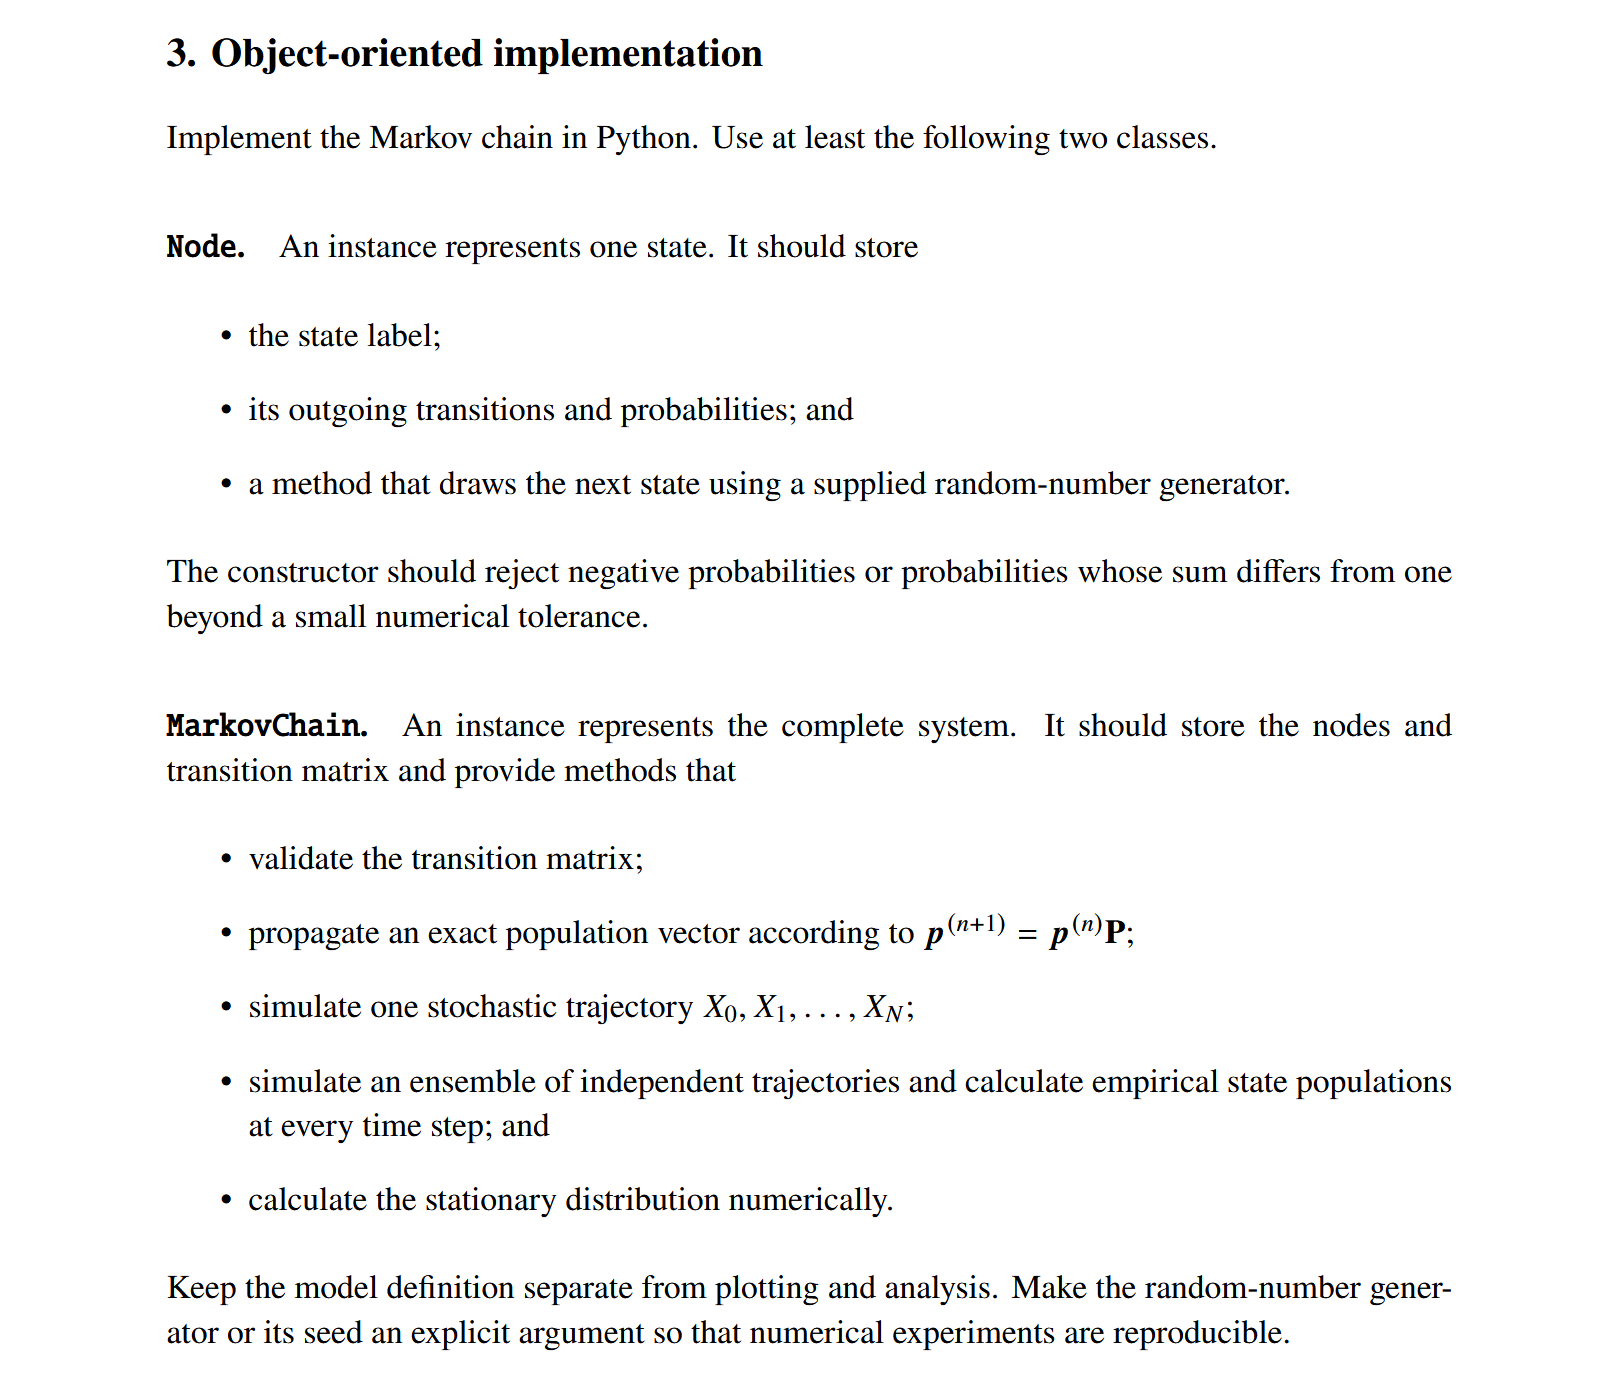

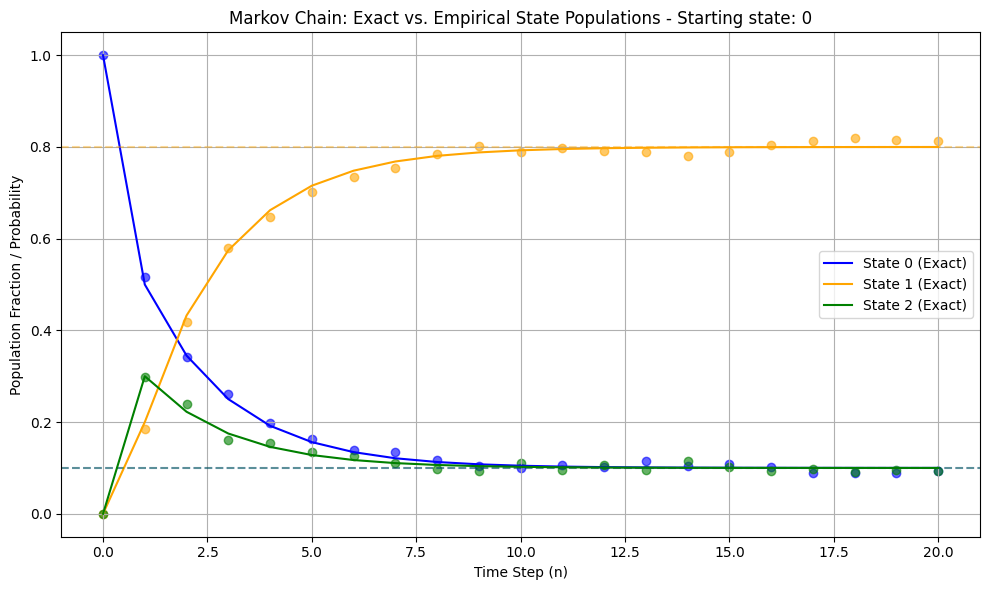

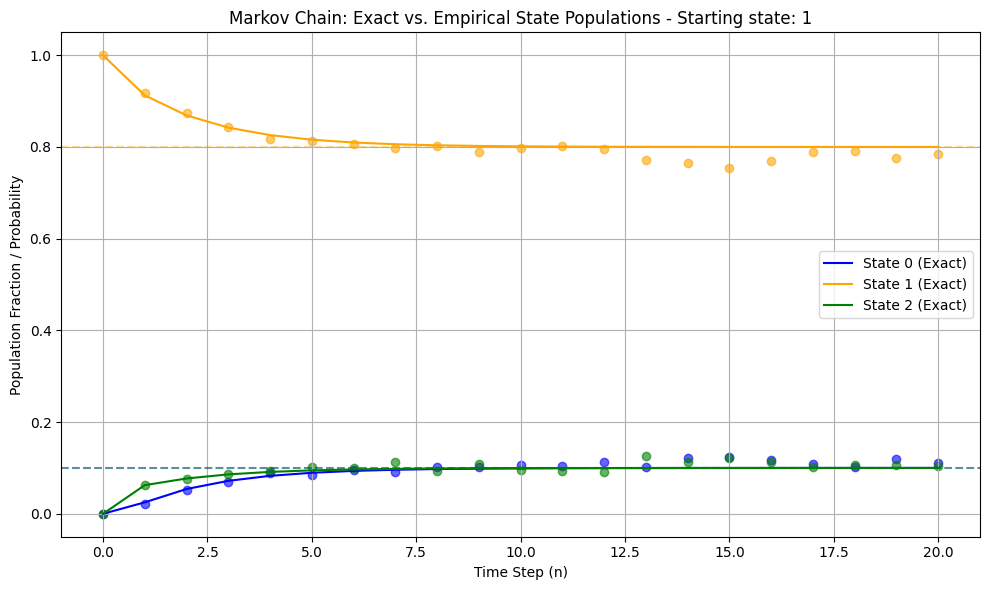

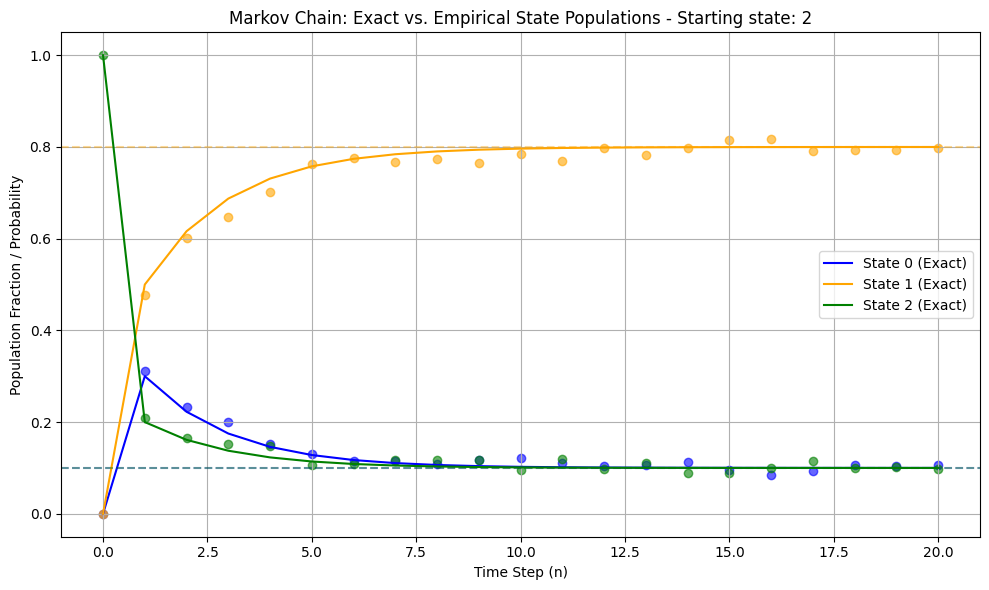

In [ ]:
class Node:
    def __init__(self, label, transitions, seed=42):
        """
        Class to represent nodes, labels are index of lists. 

        Arguments: 
            int label: Integer of the nodes position in the transition list 
            list transitions: Probability of going to node of index
            int seed: seed for random number generator 
        """
        self.label = label
        self.transitions = np.array(transitions) 

        trans_sum = np.sum(self.transitions)
        assert np.all(self.transitions >= 0), "Transition probabilities negative"
        assert (1-1e-4 < trans_sum < 1+1e-4), f"Sum of transitions are not 1, but {trans_sum:.4g}"

        # Create a dedicated random number generator for this node
        self.rng = np.random.default_rng(seed)

    def next(self):
        """
        Returns the index of the next state, chosen by the probabilities in transitions 
        """
        return self.rng.choice(len(self.transitions), p=self.transitions)


class MarkovChain:
    def __init__(self, nodes):
        """
        A class for creating a markov chain

        Arguments: 
            list nodes: a list of node classes 
        """
        self.nodes = nodes
        self.trans_matrix = np.array([node.transitions for node in nodes])

        # Verify transition matrix
        shape = self.trans_matrix.shape
        assert len(shape) == 2, "Matrix is not 2D"
        assert shape[0] == shape[1], "Matrix is not square"

    def propegate_exact(self, p_current, n=1):
        """
        Propagates the population vector exactly by one time step.
        Matches the formula: p^(n+1) = p^(n)P
        sets self.p_current to new p^(n+1)

        Arguments:
            p_current (np.ndarray): Current population distribution
            int n: number of times to run function
        """
        p_current = np.array(p_current)
        for _ in range(n):
            p_current = p_current @ self.trans_matrix

        return p_current

    def simulate_trajectory(self, start_label, N):
        """
        Simulates a single stochastic trajectory for N steps.
        
        Arguments:
            int start_label: The index of the initial state (X_0).
            int N: The number of transitions to simulate.
            
        Returns:
            list: A list of length N+1 containing the state sequence.
        """
        current_state = start_label
        trajectory = [current_state]
        
        for _ in range(N):
            current_node = self.nodes[current_state]
            next_state = current_node.next()
            
            trajectory.append(next_state)
            current_state = next_state
            
        return trajectory

    def simulate_ensemble(self, start_label, num_walkers, N):
        """
        Simulates an ensemble of walkers and calculates empirical state populations.
        
        Arguments:
            int start_label: The starting node for all walkers.
            int num_walkers: The number of independent trajectories to run.
            int N: The number of transitions to simulate.
            
        Returns:
            np.ndarray: A 2D array where each row represents the probability 
                        distribution of the walkers at that time step.
        """
        num_states = len(self.nodes)
        counts = np.zeros((N + 1, num_states))
        
        for _ in range(num_walkers):
            trajectory = self.simulate_trajectory(start_label, N)
            for time_step, state in enumerate(trajectory):
                counts[time_step, state] += 1
                
        empirical_populations = counts / num_walkers
        return empirical_populations

    def calculate_stationary_numerically(self, tolerance=1e-8, max_steps=1000):
        """
        Repeatedly propagates an initial vector until it converges to the stationary distribution.
        
        Arguments:
            float tolerance: The threshold for stopping the loop.
            int max_steps: A failsafe to prevent an infinite loop.
            
        Returns:
            np.ndarray: The numerical stationary distribution.
        """
        num_states = len(self.nodes)
        
        # Start with 100% in state 0
        current_p = np.zeros(num_states)
        current_p[0] = 1.0 
        
        for _ in range(max_steps):
            next_p = self.propegate_exact(current_p, n=1)
            
            if np.allclose(current_p, next_p, atol=tolerance):
                return next_p
                
            current_p = next_p
            
        print("Warning: Stationary distribution did not converge")
        return current_p


def plot_markov(P, seed, start_index): 
    # Initialize the nodes with different seeds to ensure independent random jumps
    n0 = Node(0, P[0], seed=seed)
    n1 = Node(1, P[1], seed=seed)
    n2 = Node(2, P[2], seed=seed)

    mc = MarkovChain([n0, n1, n2])

    # Simulation parameters
    N_steps = 20
    num_walkers = 1000
    p_start = np.zeros(3)
    p_start[start_index] = 1

    # Get empirical data (from the random walkers)
    empirical_history = mc.simulate_ensemble(start_label=start_index, 
                                            num_walkers=num_walkers, 
                                            N=N_steps)

    # Get exact data (from the matrix math)
    exact_history = [p_start]
    current_p = p_start
    for _ in range(N_steps):
        current_p = mc.propegate_exact(current_p, n=1)
        exact_history.append(current_p)
    exact_history = np.array(exact_history)

    # Get the stationary distribution to draw target lines
    stationary_dist = mc.calculate_stationary_numerically()

    # Plotting
    plt.figure(figsize=(10, 6))
    colors = ['blue', 'orange', 'green']
    labels = ['State 0', 'State 1', 'State 2']

    for i in range(3):
        # Plot exact probabilities as solid lines
        plt.plot(exact_history[:, i], color=colors[i], label=f'{labels[i]} (Exact)')
        
        # Plot empirical probabilities as dots
        plt.scatter(range(N_steps + 1), empirical_history[:, i], color=colors[i], marker='o', alpha=0.6)
        
        # Plot the stationary distribution as a dashed line
        plt.axhline(stationary_dist[i], color=colors[i], linestyle='--', alpha=0.4)

    plt.title(f"Markov Chain: Exact vs. Empirical State Populations - Starting state: {start_index}")
    plt.xlabel("Time Step (n)")
    plt.ylabel("Population Fraction / Probability")
    plt.legend(loc='center right')
    plt.grid()
    plt.tight_layout()
    plt.show()


plot_markov(P1, 42, 0)
plot_markov(P1, 20, 1)
plot_markov(P1, 2, 2)

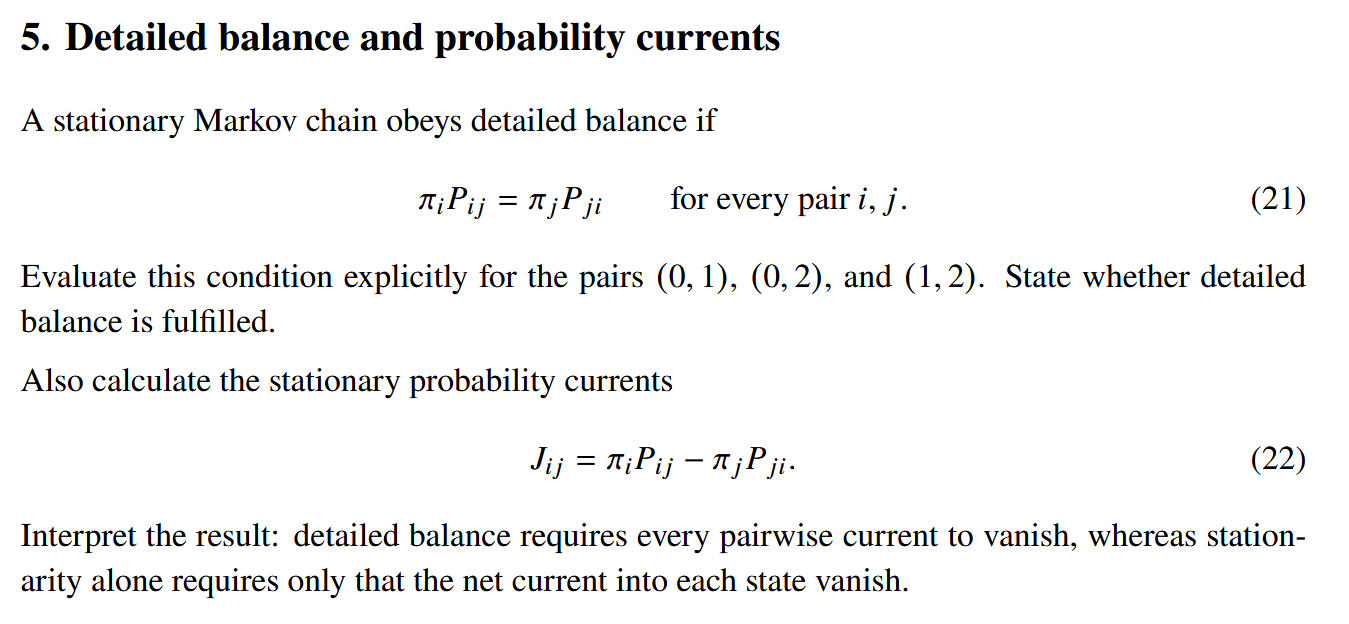

### Detailed balance and probability currents

**Detailed Balance Evaluation ($\pi_i P_{ij} = \pi_j P_{ji}$):**
*   **Pair (0,1):** $\pi_0 P_{01} = 0.1 \times 0.2 = 0.02$. $\pi_1 P_{10} = 0.8 \times 0.025 = 0.02$. (Equal)
*   **Pair (0,2):** $\pi_0 P_{02} = 0.1 \times 0.3 = 0.03$. $\pi_2 P_{20} = 0.1 \times 0.3 = 0.03$. (Equal)
*   **Pair (1,2):** $\pi_1 P_{12} = 0.8 \times 0.0625 = 0.05$. $\pi_2 P_{21} = 0.1 \times 0.5 = 0.05$. (Equal)
**Conclusion**: Detailed balance is fulfilled.

**Stationary Probability Currents ($J_{ij}$):**
Since $\pi_i P_{ij} = \pi_j P_{ji}$ for all pairs, $J_{ij} = \pi_i P_{ij} - \pi_j P_{ji} = 0$ for all $i,j$.
$$J_{01} = 0, \quad J_{02} = 0, \quad J_{12} = 0$$

**Interpretation:**
Detailed balance implies a strictly *local* pairwise equilibrium where the probability flow from state $i$ to $j$ is perfectly balanced by the flow from $j$ to $i$ ($J_{ij} = 0$). Standard stationarity alone only demands a *global* equilibrium, where the total net flow into a state matches the total flow out ($\sum_j J_{ij} = 0$), without requiring individual pairs to cancel out.

In [33]:
π = np.array([0.1, 0.8, 0.1])
J = np.zeros((3, 3))

for i in range(3):
    for j in range(3):
        if π[i]*P[i,j] != π[j]*P[j,i]:
            print(f"Not true for [{i}, {j}]") 
            J[i, j] = π[i]*P[i,j] - π[j]*P[j,i]

print(f"J = {J}") 

J = [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


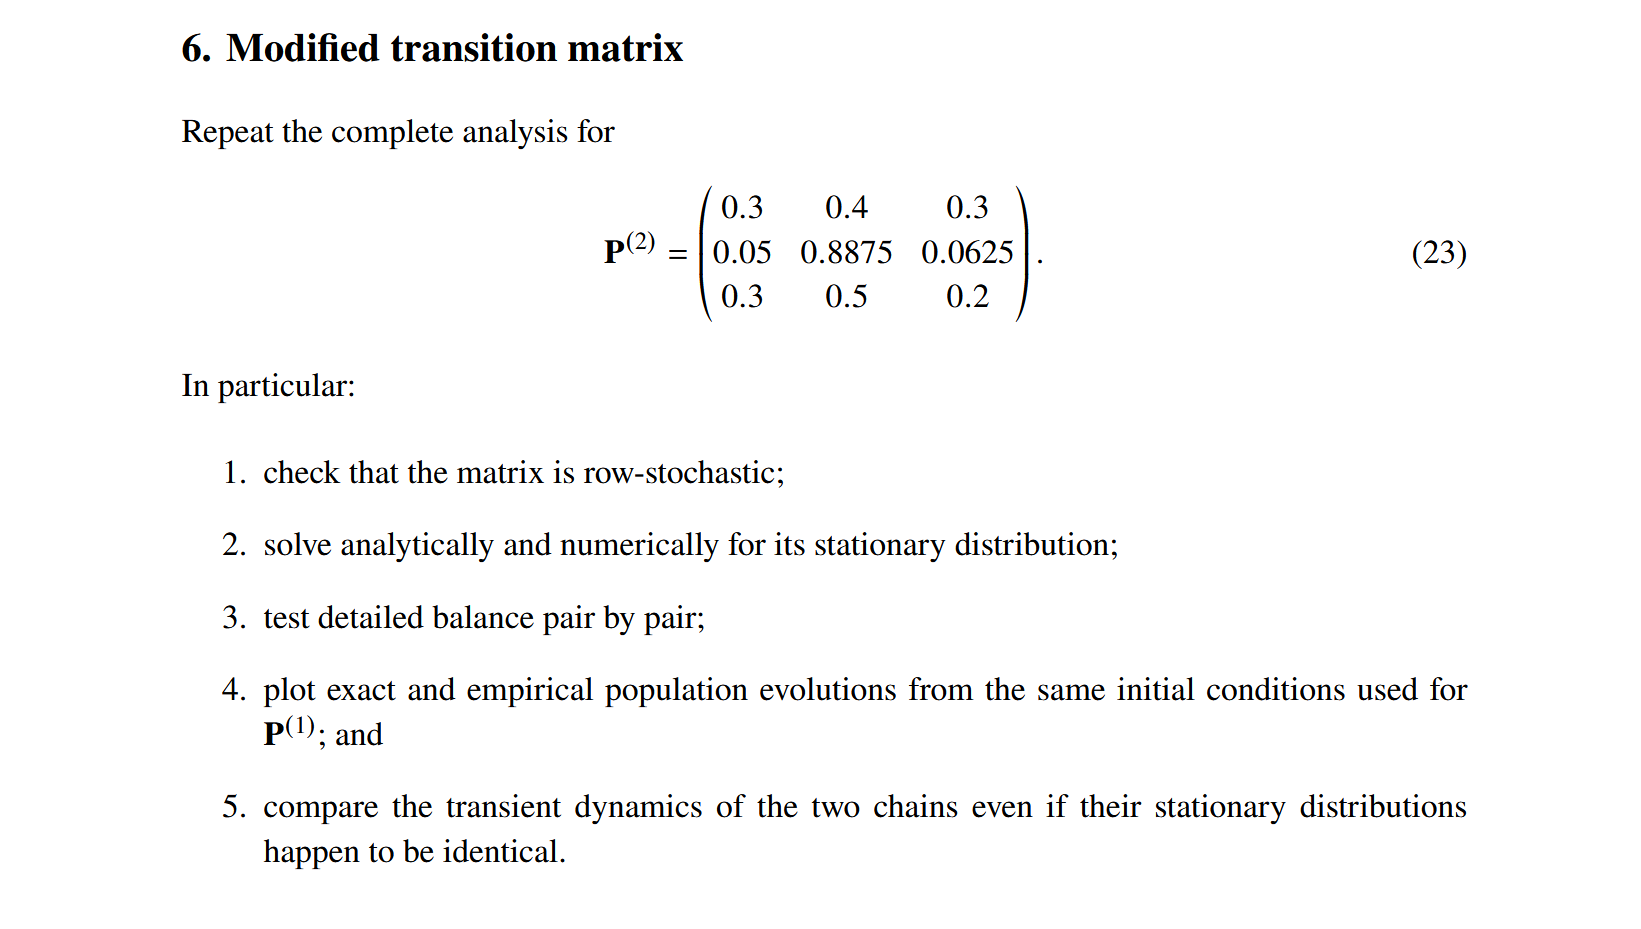


**Analytical Stationary Distribution**
1) $\pi_0 = 0.3\pi_0 + 0.05\pi_1 + 0.3\pi_2 \implies 14\pi_0 = \pi_1 + 6\pi_2$
2) $\pi_2 = 0.3\pi_0 + 0.0625\pi_1 + 0.2\pi_2 \implies 12.8\pi_2 = 4.8\pi_0 + \pi_1$
Equating both for $\pi_1$:
$$14\pi_0 - 6\pi_2 = 12.8\pi_2 - 4.8\pi_0 \implies 18.8\pi_0 = 18.8\pi_2 \implies \pi_0 = \pi_2$$
Substitute back: $\pi_1 = 14\pi_0 - 6\pi_0 = 8\pi_0$.
Normalize ($\pi_0 + 8\pi_0 + \pi_0 = 1$): $10\pi_0 = 1 \implies \pi_0 = 0.1$.
**Result:** $\pi = (0.1, 0.8, 0.1)$.

**3. Test detailed balance pair by pair**
*   **(0,1):** $\pi_0 P_{01} = 0.1 \times 0.4 = 0.04$, $\pi_1 P_{10} = 0.8 \times 0.05 = 0.04$. (Equal)
*   **(0,2):** $\pi_0 P_{02} = 0.1 \times 0.3 = 0.03$, $\pi_2 P_{20} = 0.1 \times 0.3 = 0.03$. (Equal)
*   **(1,2):** $\pi_1 P_{12} = 0.8 \times 0.0625 = 0.05$, $\pi_2 P_{21} = 0.1 \times 0.5 = 0.05$. (Equal)
Detailed balance is still fulfilled!

**5. Compare transient dynamics**
Although $P^{(1)}$ and $P^{(2)}$ share the exact same stationary distribution, their approach paths (transient dynamics) differ. As seen in the generated plots, the $P^{(2)}$ matrix converges to the stationary distribution noticeably faster than $P^{(1)}$. 

Sums of rows: [1. 1. 1.]
Eigenvalues: [ 1.          0.44382811 -0.05632811]
Eigenvector for eigenvalue 1: [0.1 0.8 0.1]
J = [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


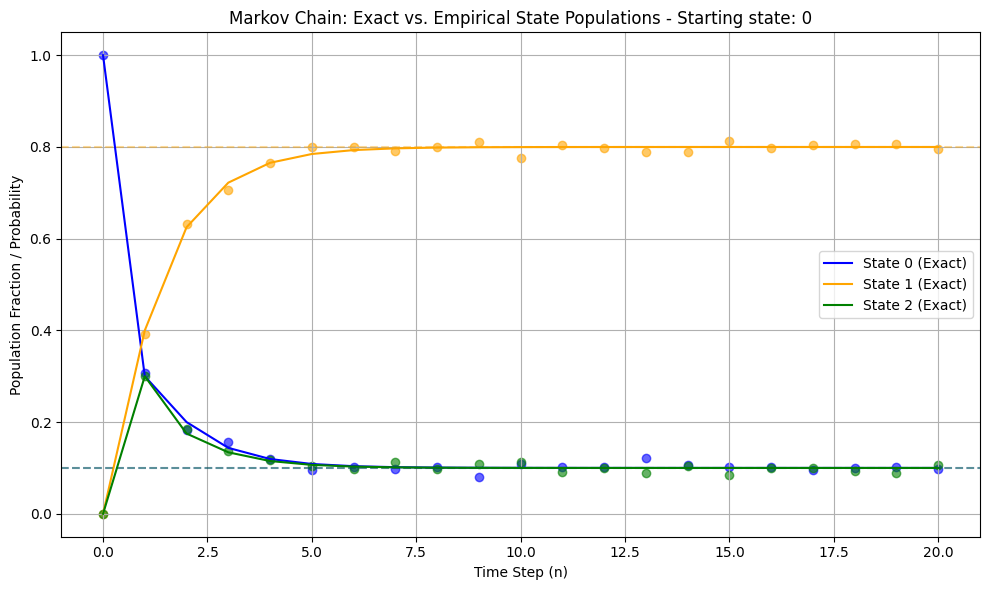

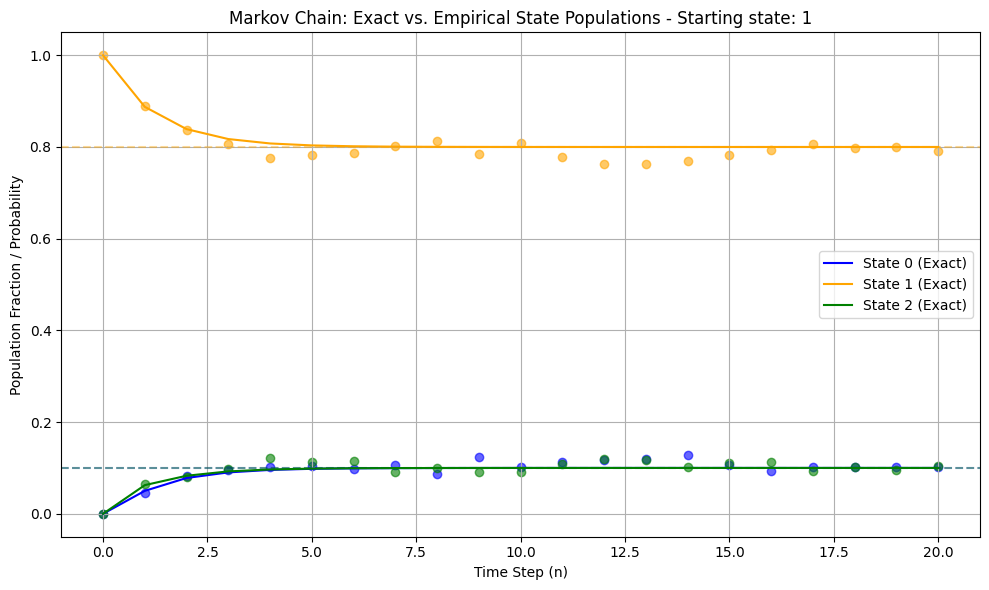

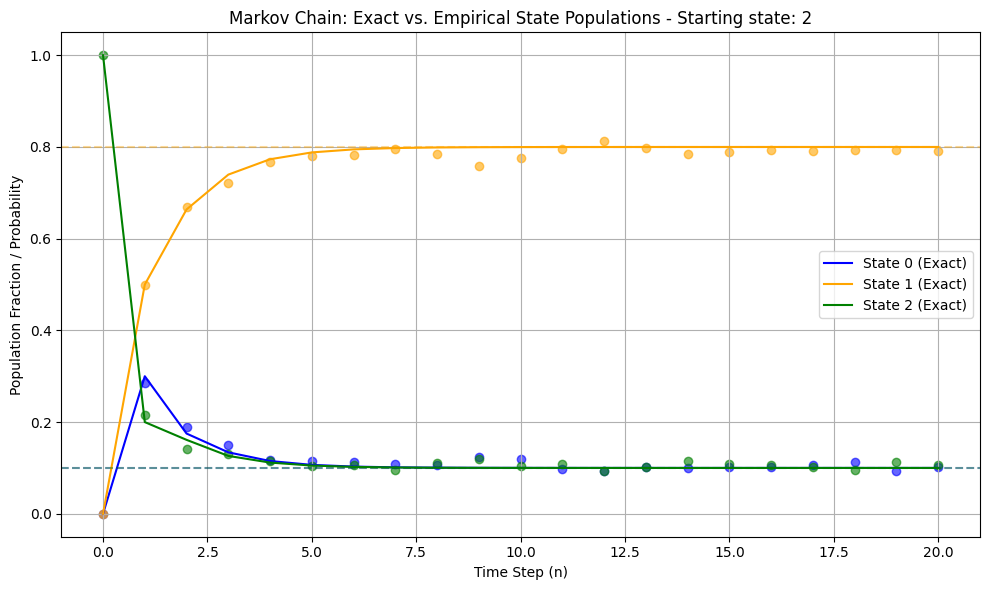

In [34]:
P2 = np.array([[0.3, 0.4, 0.3], 
              [0.05, 0.8875, 0.0625], 
              [0.3, 0.5, 0.2]])
I = np.array([1, 1, 1])
print(f"Sums of rows: {(P2 @ I)}")

res = np.linalg.eig(P2.T)
print(f"Eigenvalues: {res.eigenvalues}")
vec = res.eigenvectors[:, 0]
print(f"Eigenvector for eigenvalue 1: {vec/np.sum(vec)}")

π = np.array([0.1, 0.8, 0.1])
J = np.zeros((3, 3))

for i in range(3):
    for j in range(3):
        if π[i]*P2[i,j] != π[j]*P2[j,i]:
            print(f"Not true for [{i}, {j}]") 
            J[i, j] = π[i]*P2[i,j] - π[j]*P2[j,i]

print(f"J = {J}") 

plot_markov(P2, 42, 0)
plot_markov(P2, 20, 1)
plot_markov(P2, 2, 2)